#Installing and importring libraries

In [ ]:
!pip install keras joblib scipy keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.6 MB/s eta 0:00:00


In [ ]:

!pip -q install -U "plotly==5.24.1" "kaleido==0.2.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pandas import DataFrame
# Pre-procces
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import seaborn as sns
# Clasification
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
# Evaluation metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
import multiprocessing
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, roc_auc_score
import tensorflow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
from tensorflow.keras import layers
from tensorflow.keras import regularizers
import keras
from keras.layers import Dense
from sklearn.utils import class_weight
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2

from scipy.stats import reciprocal, uniform
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
import importlib, subprocess, sys, os
import plotly.io as pio

# PATHS AND PARAMETERS

In [ ]:
# ============================================================
# 0) PATHS AND PARAMETERS
# ============================================================
import os
import dill
# --- BASE MODEL artifacts ---

MODEL_BASE_FULL_PATH =  "/content/sample_data/multi_input_transfer_best_v2.keras"


# --- New dataset ---
NEW_DATA_PATH = "/content/sample_data/CIBMTR.xlsx"
NEW_SHEET = None
TARGET = "acute_GvHD_II_III_IV"


# Tuner
MAX_TRIALS_TRANSFER = 20
EPOCHS_TRANSFER = 1000
BATCH_SIZE_TRANSFER = 16

print("Base model:", MODEL_BASE_FULL_PATH)
print("New dataset:", NEW_DATA_PATH)


Base model: /content/sample_data/multi_input_transfer_best_v2.keras
New dataset: /content/sample_data/CIBMTR.xlsx


# IMPORTS AND SEEDS

In [ ]:
# ============================================================
# 1) IMPORTS AND SEEDS
# ============================================================
import random
import json
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score
)

import joblib
import keras_tuner as kt

os.environ["PYTHONHASHSEED"] = "0"
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


# LOAD NEW DATASET AND DEFINE X_existing / X_new

In [ ]:
# ============================================================
# 4) LOAD NEW DATASET AND DEFINE X_existing / X_new
# ============================================================
if NEW_SHEET is None:
    df = pd.read_excel(NEW_DATA_PATH)
else:
    df = pd.read_excel(NEW_DATA_PATH, sheet_name=NEW_SHEET)

assert TARGET in df.columns, f"Target column '{TARGET}' was not found in the new dataset"

print("New dataset shape (raw):", df.shape)
df.head()


New dataset shape (raw): (603, 61)


,cytogene,risk_group,cond_new2,gvhdgp3,pkinetbu,intxsurv,intxipn,stem_cell_source,atgcampathgp,karnofcat,...,chfren,intxchfren,chfrencomp,ipn,ipncomp,yeargp,pseudoid,pseudoccn,distat,disease
0,2,high,3,2,0,120.26,120.26,bone_marrow,4,1,...,0,120.26,0,0,0,1,58133458,90121713,CR1,Leukemia
1,2,high,3,5,1,81.28,81.28,bone_marrow,4,1,...,0,81.28,0,0,0,1,58136437,90123157,CR1,Leukemia
2,2,high,3,6,1,91.41,91.41,bone_marrow,4,1,...,0,91.41,0,0,0,1,58143119,90123247,CR1,Leukemia
3,2,high,3,6,1,116.38,116.38,cord_blood,4,1,...,0,116.38,0,0,0,1,58144296,90121985,CR2,Leukemia
4,2,high,3,3,1,122.07,122.07,cord_blood,2,1,...,0,122.07,0,0,0,1,58143885,90121753,CR1,Leukemia


In [ ]:
df=df.loc[:,['risk_group','agegp','karnofcat','stem_cell_source','hctci2gp','distat','cytogene','site_dx','mrd','HLA_mismatch','gvhdgp3','cond_new2','pkinetbu','atgcampathgp','tbigp','acute_GvHD_II_III_IV']]

In [ ]:
df=df.dropna()
df.shape

(583, 16)

#Preproces the Dataset and spliting

In [ ]:
# === df_nuevo ya cargado con TODAS las columnas ===


VAL_SIZE  = 0.20
TEST_SIZE = 0.20
SEED = 16

TARGET = "acute_GvHD_II_III_IV"                     # ajusta
y = df[TARGET].astype(int)
X_all = df.drop(columns=[TARGET]).copy()

# 1) split train vs temp (val+test)
train_idx, temp_idx = train_test_split(
    np.arange(len(X_all)),
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=y,
    random_state=SEED
)

# 2) split temp -> val y test en la proporción pedida
temp_y = y.iloc[temp_idx]
val_ratio_within_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
val_rel_idx, test_rel_idx = train_test_split(
    np.arange(len(temp_idx)),
    test_size=(1 - val_ratio_within_temp),
    stratify=temp_y,
    random_state=SEED
)

val_idx  = np.asarray(temp_idx)[val_rel_idx]
test_idx = np.asarray(temp_idx)[test_rel_idx]


X_train_all, X_val_all, X_test_all = X_all.iloc[train_idx], X_all.iloc[val_idx], X_all.iloc[test_idx]
y_train,     y_val,     y_test     = y.iloc[train_idx],   y.iloc[val_idx],   y.iloc[test_idx]

print("Sizes ->",
      "train:", len(X_train_all),
      "val:",   len(X_val_all),
      "test:",  len(X_test_all))



Sizes -> train: 349 val: 117 test: 117


In [ ]:
# --- Definir base_feature_names / raw_columns de forma robusta ---
import json, numpy as np, pandas as pd, os, joblib

# Artefactos del base (ajusta rutas si difieren)
#BASE_META_PATH = "feature_meta.json"
#BASE_PREPROC_PATH = "preprocessor.joblib"

# Cargar preprocesador del base
pre_base = joblib.load('/content/sample_data/preprocessor.joblib')

def get_raw_columns_from_pre(pre):
    raw_cols = []
    for name, trans, cols in pre.transformers_:
        if name == "remainder":
            continue
        if isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
            raw_cols.extend(list(cols))
        elif isinstance(cols, slice):
            raise ValueError("El preprocesador usa slices; no puedo reconstruir nombres.")
        else:
            raise ValueError(f"Selector de columnas no soportado: {type(cols)}")
    # único y en orden
    seen, ordered = set(), []
    for c in raw_cols:
        if c not in seen:
            ordered.append(c); seen.add(c)
    return ordered

# 1) Intentar leer meta
raw_columns = None
ohe_feature_names = None
if os.path.exists('/content/sample_data/meta.json'):
    try:
        with open('/content/sample_data/meta.json', "r") as f:
            meta = json.load(f)
        raw_columns = meta.get("raw_columns")
        ohe_feature_names = meta.get("ohe_feature_names")
    except Exception:
        pass

# 2) Completar/Reconstruir si falta algo
if raw_columns is None:
    raw_columns = get_raw_columns_from_pre(pre_base)
if ohe_feature_names is None:
    try:
        ohe_feature_names = list(map(str, pre_base.get_feature_names_out()))
    except Exception:
        ohe_feature_names = [f"f{i}" for i in range(len(raw_columns))]

# 3) Si lo que tenías antes eran nombres OHE, detectarlo y corregir
#    (base_feature_names puede no existir aún; lo tratamos como lista vacía)
try:
    base_feature_names
except NameError:
    base_feature_names = []

df_cols = set(X_all.columns)  # X_all = df_nuevo sin el TARGET
# Si base_feature_names no está en las columnas crudas del df, asumimos que eran OHE
if base_feature_names and not any(col in df_cols for col in base_feature_names):
    print("⚠️ Detectado: base_feature_names parecían OHE. Usaré columnas crudas del preprocesador.")
    base_feature_names = raw_columns
elif not base_feature_names:
    # Si no había nada definido, usa crudas por defecto
    base_feature_names = raw_columns

# 4) Verificación
missing = [c for c in base_feature_names if c not in df_cols]
if missing:
    raise KeyError(f"Estas columnas crudas del base no existen en el dataset nuevo: {missing}")

# 5) Persistir meta consolidada (para no repetir esta lógica)
with open('/content/sample_data/preprocessor_meta.json', "w") as f:
    json.dump({"raw_columns": raw_columns,
               "ohe_feature_names": ohe_feature_names}, f, indent=2)

print("✅ Meta consolidada. Columnas crudas del base:", len(base_feature_names))

✅ Meta consolidada. Columnas crudas del base: 4


##Final sets


In [ ]:
# ==================== SEPARAR ENTRADAS: EXISTING vs NEW ====================
# Usa las columnas CRUDAS del base (no las OHE)
# raw_columns viene de feature_meta.json o del pre_base (según lo que guardaste)
OUT_DIR = "outputs_fedrated_tuned_copy2"
os.makedirs(OUT_DIR, exist_ok=True)
X_train_exist_raw = X_train_all[raw_columns].copy()
X_val_exist_raw   = X_val_all[raw_columns].copy()
X_test_exist_raw  = X_test_all[raw_columns].copy()

X_new_cols = [c for c in X_all.columns if c not in raw_columns]
X_train_new_raw = X_train_all[X_new_cols].copy()
X_val_new_raw   = X_val_all[X_new_cols].copy()
X_test_new_raw  = X_test_all[X_new_cols].copy()

# ==================== TRANSFORMACIONES ====================
# EXISTING -> MISMO preprocesador del BASE (NO refit)
X_train_existing = pre_base.transform(X_train_exist_raw)
X_val_existing   = pre_base.transform(X_val_exist_raw)
X_test_existing  = pre_base.transform(X_test_exist_raw)

# NEW -> su propio preprocesador (fit SOLO con train)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

if len(X_new_cols) > 0:
    #num_cols_new = X_train_new_raw.select_dtypes(include=["number","float","int"]).columns.tolist()
    cat_cols_new=df.loc[:,['karnofcat','hctci2gp','distat','cytogene','site_dx','mrd','gvhdgp3','cond_new2','pkinetbu','atgcampathgp']].columns.to_list()

    pre_new = ColumnTransformer(
        transformers=[
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), cat_cols_new),

        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    X_train_new = pre_new.fit_transform(X_train_new_raw)
    X_val_new   = pre_new.transform(X_val_new_raw)
    X_test_new  = pre_new.transform(X_test_new_raw)

    os.makedirs(OUT_DIR, exist_ok=True)
    joblib.dump(pre_new, os.path.join(OUT_DIR, "preprocessor_new.joblib"))
else:
    # Sin columnas nuevas: crea matrices vacías (útil para mantener API)
    X_train_new = np.zeros((len(X_train_all), 0), dtype=float)
    X_val_new   = np.zeros((len(X_val_all),   0), dtype=float)
    X_test_new  = np.zeros((len(X_test_all),  0), dtype=float)
    pre_new = None

print("Shapes EXISTING ->",
      "train:", X_train_existing.shape,
      "val:",   X_val_existing.shape,
      "test:",  X_test_existing.shape)
print("Shapes NEW ->",
      "train:", X_train_new.shape,
      "val:",   X_val_new.shape,
      "test:",  X_test_new.shape)

# (Opcional) guardar matrices para relanzar rápido
np.savez_compressed(
    os.path.join(OUT_DIR , "matrices_train_val_test.npz"),
    X_train_existing=X_train_existing, X_val_existing=X_val_existing, X_test_existing=X_test_existing,
    X_train_new=X_train_new, X_val_new=X_val_new, X_test_new=X_test_new,
    y_train=y_train.values, y_val=y_val.values, y_test=y_test.values
)

Shapes EXISTING -> train: (349, 9) val: (117, 9) test: (117, 9)
Shapes NEW -> train: (349, 39) val: (117, 39) test: (117, 39)


# Evaluacion en test

In [ ]:
# ============================================================
# SCRIPT: Evaluación Robusta de Arquitectura Única
# - Entrena 10 semillas independientes del modelo
# - Evalúa en 7 distribuciones de test (10 x 7 = 70 evaluaciones)
# - Umbral óptimo calculado dinámicamente en cada partición
# - Incluye matriz de confusión agregada (Media ± Std sobre N=70)
# ============================================================
import os, re, glob, gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.utils import resample
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score, precision_recall_curve,
    confusion_matrix, roc_curve, auc as sk_auc, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)

# -------------------------
# 1. Rutas y configuración
# -------------------------
SINGLE_MODEL_PATH = "/content/sample_data/multi_input_transfer_best_v2.keras" # <--- Ruta a TU modelo base
OUTPUT_DIR        = "/content/sample_data/ensemble_eval_70_evals"        # Carpeta de salida
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # 10 semillas para entrenar el modelo
TEST_SEEDS  = [10, 20, 30, 40, 50, 60, 70]   # 7 semillas para el test set

EPOCHS = 20
BATCH_SIZE = 32

# MATRICES DE ENTRENAMIENTO (Necesarias para inicializar cada semilla)
Xtr_exist = np.asarray(X_train_existing)
Xtr_new   = np.asarray(X_train_new)
ytr       = np.asarray(y_train).ravel()

# MATRICES DE TEST ORIGINALES
Xte_exist_orig = np.asarray(X_test_existing)
Xte_new_orig   = np.asarray(X_test_new)
yte_orig       = np.asarray(y_test).ravel()

# -------------------------
# 2. Helpers
# -------------------------
def pr_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2: return np.nan
    p, r, _ = precision_recall_curve(y_true, y_prob)
    return sk_auc(r, p)

def safe_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2: return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def get_best_threshold_f1(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-7)
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx]

def plot_and_save_roc(y_true, y_prob, title, path_png):
    if len(np.unique(y_true)) < 2: return None, None, None
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = sk_auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC={auc_val:.3f}")
    plt.plot([0,1], [0,1], "--", lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(title); plt.legend(); plt.grid(alpha=0.2)
    plt.savefig(path_png, dpi=200, bbox_inches="tight")
    plt.close()
    return fpr, tpr, auc_val

def plot_and_save_confusion(y_true, y_pred, title, path_pdf, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1], normalize='true' if normalize else None)
    plt.figure(figsize=(5,4))
    im = plt.imshow(cm, interpolation='nearest', aspect='auto', vmin=0, vmax=1 if normalize else None)
    plt.title(title); plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = np.arange(2)
    plt.xticks(ticks, ['0','1']); plt.yticks(ticks, ['0','1'])
    thresh = cm.max() / 2. if cm.size else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, txt, ha="center", va="center", color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True label"); plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(path_pdf, format="pdf", bbox_inches="tight")
    plt.close()

def plot_aggregated_confusion(mean_cm, std_cm, n_evals, title, path_pdf):
    plt.figure(figsize=(5,4))
    im = plt.imshow(mean_cm, interpolation='nearest', aspect='auto', vmin=0, vmax=1)
    plt.title(f"{title}\n(N = {n_evals} evaluaciones)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = np.arange(2)
    plt.xticks(ticks, ['0','1']); plt.yticks(ticks, ['0','1'])
    thresh = mean_cm.max() / 2. if mean_cm.size else 0.5
    for i in range(2):
        for j in range(2):
            txt = f"{mean_cm[i, j]:.3f}\n(±{std_cm[i, j]:.3f})"
            plt.text(j, i, txt, ha="center", va="center",
                     color="white" if mean_cm[i, j] > thresh else "black")
    plt.ylabel("True label"); plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(path_pdf, format="pdf", bbox_inches="tight")
    plt.close()

# -------------------------
# 3. Cargar Arquitectura Base
# -------------------------
if not os.path.exists(SINGLE_MODEL_PATH):
    raise FileNotFoundError(f"No se encontró el modelo base en {SINGLE_MODEL_PATH}")

print("⏳ Cargando arquitectura base...")
base_model = tf.keras.models.load_model(SINGLE_MODEL_PATH, compile=True)
base_loss = base_model.loss if base_model.loss else 'binary_crossentropy'

# Diccionarios y listas para resultados
results_by_test_dist = {t_seed: [] for t_seed in TEST_SEEDS}
roc_curves = []
cms_by_seed_pair = [] # Almacenará las 70 matrices normalizadas

GLOBAL_MODEL_NAME = "Transfer_Architecture" # Identificador único para agrupar las 70 iteraciones

print(f"🔍 Evaluando {len(MODEL_SEEDS)} Semillas de Modelo x {len(TEST_SEEDS)} Distribuciones de Test...")

# -------------------------
# 4. Bucle Exterior: Modelos
# -------------------------
for m_seed in MODEL_SEEDS:
    print(f"\n🚀 --- Inicializando y Entrenando Modelo con Semilla {m_seed} ---")

    tf.keras.backend.clear_session()
    np.random.seed(m_seed)
    tf.random.set_seed(m_seed)

    model = tf.keras.models.clone_model(base_model)
    try:
        opt_config = base_model.optimizer.get_config()
        optimizer = base_model.optimizer.__class__.from_config(opt_config)
    except:
        optimizer = 'adam'

    model.compile(optimizer=optimizer, loss=base_loss, metrics=['accuracy'])

    # Entrenar el modelo
    model.fit([Xtr_exist, Xtr_new], ytr, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

    # -------------------------
    # 5. Bucle Interior: Test Sets
    # -------------------------
    for t_seed in TEST_SEEDS:
        print(f"   -> Evaluando en Test Set (Semilla {t_seed})")

        # 1. Remuestreo del conjunto de test
        Xte_ex_boot, Xte_new_boot, yte_boot = resample(
            Xte_exist_orig, Xte_new_orig, yte_orig,
            random_state=t_seed, stratify=yte_orig
        )

        # 2. Predicción
        y_prob_transfer = model.predict([Xte_ex_boot, Xte_new_boot], verbose=0).ravel()

        # 3. Umbral Dinámico
        best_thr = get_best_threshold_f1(yte_boot, y_prob_transfer)
        y_pred = (y_prob_transfer >= best_thr).astype(int)

        # 4. Métricas
        acc = accuracy_score(yte_boot, y_pred)
        f1  = f1_score(yte_boot, y_pred, zero_division=0) if len(np.unique(yte_boot))>1 else np.nan
        auc = safe_auc(yte_boot, y_prob_transfer)
        pra = pr_auc(yte_boot, y_prob_transfer)
        mcc = matthews_corrcoef(yte_boot, y_pred) if len(np.unique(yte_boot))>1 else np.nan
        bal_acc = balanced_accuracy_score(yte_boot, y_pred) if len(np.unique(yte_boot))>1 else np.nan

        # 5. Matriz de Confusión e Integración Agregada
        cm_counts = confusion_matrix(yte_boot, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm_counts.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        row_sums = cm_counts.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm_counts, row_sums, out=np.zeros_like(cm_counts, dtype=float), where=row_sums!=0)

        cms_by_seed_pair.append({
            "model": GLOBAL_MODEL_NAME, "model_seed": m_seed, "test_seed": t_seed, "cm_norm": cm_norm
        })

        # 6. Exportar reportes y gráficos individuales
        file_suffix = f"mS{m_seed}_tS{t_seed}"

        cr_dict = classification_report(yte_boot, y_pred, labels=[0,1], output_dict=True, zero_division=0)
        pd.DataFrame(cr_dict).transpose().to_csv(os.path.join(OUTPUT_DIR, f"{file_suffix}_classification_report.csv"), index=True)

        roc_png = os.path.join(OUTPUT_DIR, f"{file_suffix}_ROC.png")
        fpr, tpr, auc_curve = plot_and_save_roc(yte_boot, y_prob_transfer, f"ROC - mSeed {m_seed} (tSeed {t_seed})", roc_png)
        if fpr is not None:
            roc_curves.append((fpr, tpr, f"mS{m_seed}_tS{t_seed} (AUC={auc_curve:.3f})"))

        cm_pdf = os.path.join(OUTPUT_DIR, f"{file_suffix}_confusion_matrix.pdf")
        cmn_pdf = os.path.join(OUTPUT_DIR, f"{file_suffix}_confusion_matrix_norm.pdf")
        plot_and_save_confusion(yte_boot, y_pred, f"CM - {file_suffix}", cm_pdf, normalize=False)
        plot_and_save_confusion(yte_boot, y_pred, f"Norm CM - {file_suffix}", cmn_pdf, normalize=True)

        results_by_test_dist[t_seed].append({
            "model": GLOBAL_MODEL_NAME, "model_seed": m_seed, "test_seed": t_seed, "threshold_used": float(best_thr),
            "test_f1": f1, "test_auc": auc, "test_acc": acc, "test_pr_auc": pra,
            "test_mcc": mcc, "test_bal_acc": bal_acc,
            "test_sensitivity": sensitivity, "test_specificity": specificity
        })

    del model
    gc.collect()

# -------------------------
# 6. Exportar a Excel y Resúmenes Finales
# -------------------------
output_excel = os.path.join(OUTPUT_DIR, "Evaluacion_NN_70_Iteraciones.xlsx")
all_rows = []

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    for t_seed, rows in results_by_test_dist.items():
        if len(rows) > 0:
            all_rows.extend(rows)
            df_dist = pd.DataFrame(rows).sort_values(by=["model_seed"])
            df_dist.to_excel(writer, sheet_name=f"Test_Seed_{t_seed}", index=False)

summary = pd.DataFrame(all_rows)
summary.to_csv(os.path.join(OUTPUT_DIR, "resumen_total_flat.csv"), index=False)

todas_las_metricas = [
    "test_f1", "test_auc", "test_acc", "test_pr_auc",
    "test_mcc", "test_bal_acc", "test_sensitivity", "test_specificity"
]

agg = summary[todas_las_metricas].agg(["mean","std"])
agg.to_csv(os.path.join(OUTPUT_DIR, "resumen_mean_std.csv"))

print(f"\n✅ Evaluación exitosa. Evaluaciones totales: {len(summary)}")
print(f"✅ Resultados guardados en Excel: {output_excel}")

# Intervalos de Confianza (95% CI)
n_evaluaciones = len(summary)
alpha = 0.95

print("\n📊 Intervalos de Confianza (95% CI) para el paper:")
if n_evaluaciones > 1:
    t_critico = stats.t.ppf((1 + alpha) / 2., n_evaluaciones - 1)
    ci_95 = summary[todas_las_metricas].apply(lambda x: t_critico * (np.std(x, ddof=1) / np.sqrt(n_evaluaciones)))

    for metric in ci_95.index:
        mean_val = agg.loc["mean", metric]
        ci_val = ci_95[metric]
        print(f"{metric}: {mean_val:.3f} ± {ci_val:.3f} (95% CI: [{mean_val - ci_val:.3f}, {mean_val + ci_val:.3f}])")

# -------------------------
# 7. Gráficos Globales (ROC y CM Agregada)
# -------------------------
# ROC combinada general (70 curvas en una imagen)
if roc_curves:
    plt.figure(figsize=(7,6))
    for fpr, tpr, label in roc_curves:
        plt.plot(fpr, tpr, alpha=0.1, lw=1) # Alpha bajito para no saturar visualmente
    xs = np.linspace(0,1,400)
    interps = [np.interp(xs, fpr, tpr) for fpr, tpr, _ in roc_curves]
    mean_tpr = np.mean(interps, axis=0)
    mean_auc = sk_auc(xs, mean_tpr)
    plt.plot(xs, mean_tpr, lw=2, color="red", label=f"Mean ROC (AUC={mean_auc:.3f})")
    plt.plot([0,1],[0,1],"--",color="black",lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC Global Combinada ({len(roc_curves)} evaluaciones)")
    plt.legend(loc="lower right"); plt.grid(alpha=0.2)
    plt.savefig(os.path.join(OUTPUT_DIR, "ROC_Global_70_Iteraciones.png"), dpi=300, bbox_inches="tight")
    plt.close()

# Matriz de Confusión Agregada sobre las 70 iteraciones
print("\n🧩 Generando Matriz de Confusión Global Agregada...")
cms_df = pd.DataFrame(cms_by_seed_pair)

# Agrupamos por el nombre global (contendrá las 70 matrices)
for model_name, group in cms_df.groupby("model"):
    stacked = np.stack(group["cm_norm"].to_numpy())  # shape (70, 2, 2)
    mean_cm = stacked.mean(axis=0)
    std_cm  = stacked.std(axis=0)
    n_evals = stacked.shape[0]

    out_pdf = os.path.join(OUTPUT_DIR, "Global_CM_Agregada_70_Evals.pdf")
    plot_aggregated_confusion(
        mean_cm, std_cm, n_evals,
        title=f"Matriz de Confusión Agregada",
        path_pdf=out_pdf
    )
    print(f"  ✅ Matriz combinada ({n_evals} evals) generada -> {out_pdf}")

print("\n✅ Proceso Finalizado.")

⏳ Cargando arquitectura base...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


🔍 Evaluando 10 Semillas de Modelo x 7 Distribuciones de Test...

🚀 --- Inicializando y Entrenando Modelo con Semilla 0 ---
   -> Evaluando en Test Set (Semilla 10)
   -> Evaluando en Test Set (Semilla 20)
   -> Evaluando en Test Set (Semilla 30)
   -> Evaluando en Test Set (Semilla 40)
   -> Evaluando en Test Set (Semilla 50)
   -> Evaluando en Test Set (Semilla 60)
   -> Evaluando en Test Set (Semilla 70)

🚀 --- Inicializando y Entrenando Modelo con Semilla 1 ---
   -> Evaluando en Test Set (Semilla 10)
   -> Evaluando en Test Set (Semilla 20)
   -> Evaluando en Test Set (Semilla 30)
   -> Evaluando en Test Set (Semilla 40)
   -> Evaluando en Test Set (Semilla 50)
   -> Evaluando en Test Set (Semilla 60)
   -> Evaluando en Test Set (Semilla 70)

🚀 --- Inicializando y Entrenando Modelo con Semilla 2 ---
   -> Evaluando en Test Set (Semilla 10)
   -> Evaluando en Test Set (Semilla 20)
   -> Evaluando en Test Set (Semilla 30)
   -> Evaluando en Test Set (Semilla 40)
   -> Evaluando en Te

In [ ]:
model = tf.keras.models.load_model(MODEL_BASE_FULL_PATH, compile=False)

#Shap

X_train_existing shape: (349, 9)
X_train_new shape: (349, 39)
X_train_all shape: (349, 48)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
13400/13400 ━━━━━━━━━━━━━━━━━━━━ 14s 1

/tmp/ipykernel_1401/3389127133.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


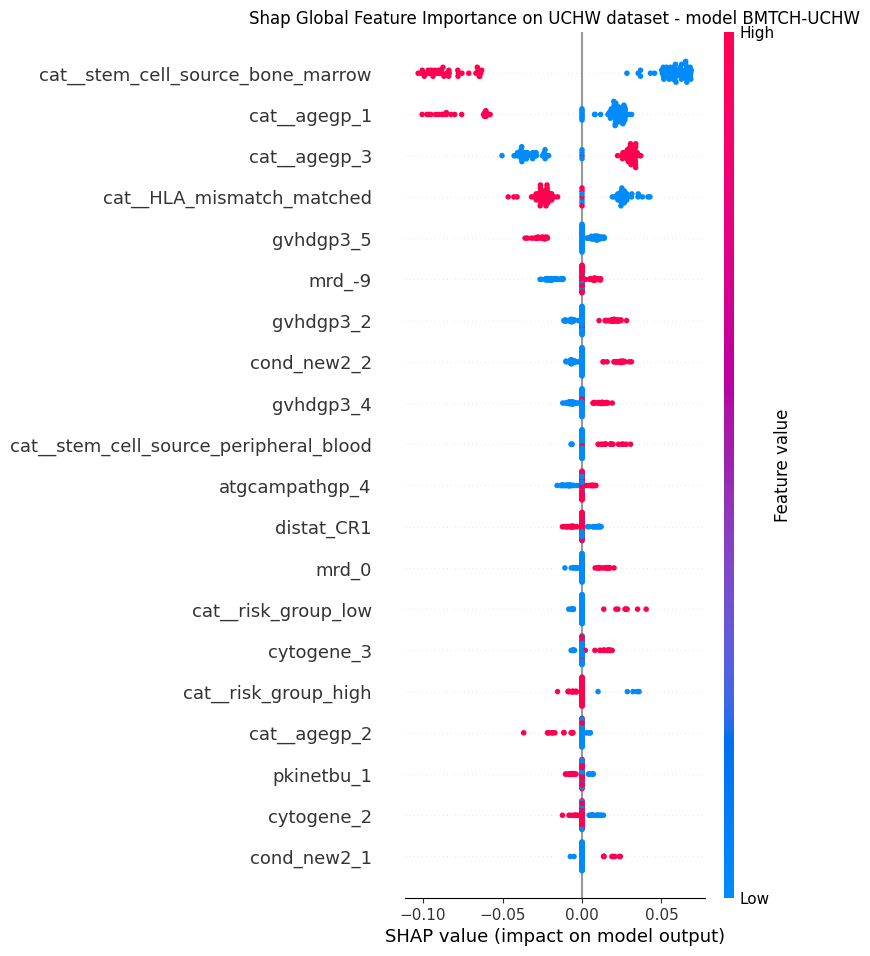

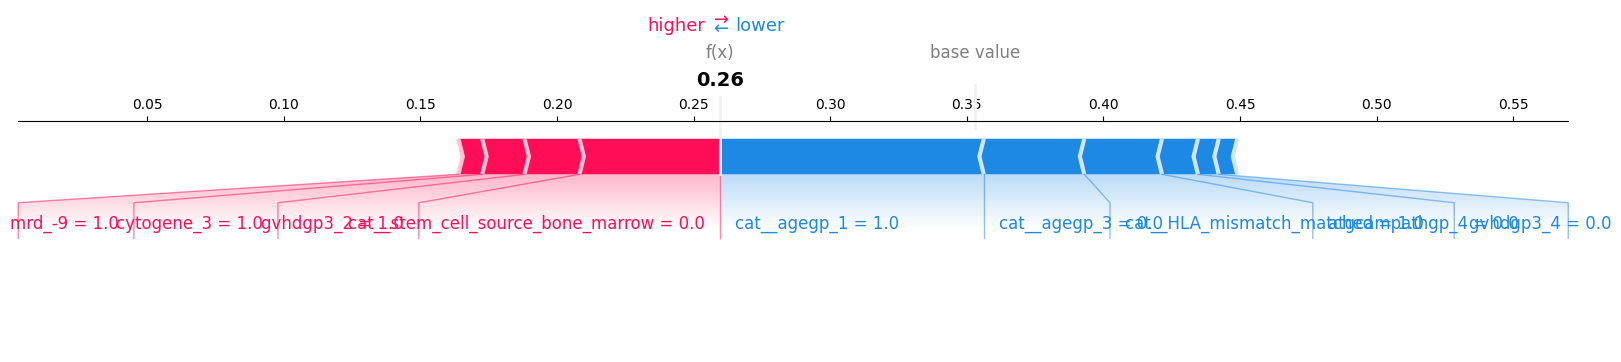

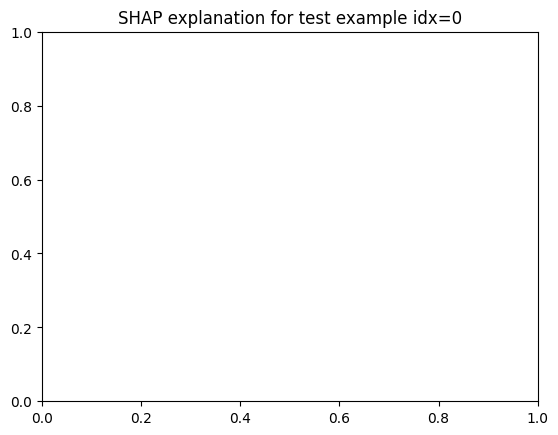

In [ ]:
# ============================================================
# SHAP for model model_308 (two inputs: X_existing + X_new)
# ============================================================

!pip install shap

import shap
import numpy as np
import matplotlib.pyplot as plt
SEED=308
# ------------------------------------------------------------
# 1) Build combined matrices for SHAP
# ------------------------------------------------------------
X_train_all = np.hstack([X_train_existing, X_train_new])
X_test_all  = np.hstack([X_test_existing,  X_test_new])

n_exist = X_train_existing.shape[1]
n_new   = X_train_new.shape[1]

print("X_train_existing shape:", X_train_existing.shape)
print("X_train_new shape:",      X_train_new.shape)
print("X_train_all shape:",      X_train_all.shape)

# ------------------------------------------------------------
# 2) Prediction wrapper (splits existing / new)
# ------------------------------------------------------------
def model_308_predict(X):
    """
    X: array 2D (n_samples, n_exist + n_new)
    Devuelve probabilidades (vector 1D).
    """
    X = np.array(X)
    X_e = X[:, :n_exist]
    X_n = X[:, n_exist:]
    return model.predict([X_e, X_n]).ravel()

# ------------------------------------------------------------
# 3) Background + test sample for SHAP
# ------------------------------------------------------------
SEED = 308
background = shap.utils.sample(X_train_all, 200, random_state=SEED)
X_test_sample = shap.utils.sample(X_test_all, 100, random_state=SEED)

explainer = shap.KernelExplainer(model_308_predict, background)


shap_values = explainer.shap_values(X_test_sample)

# Binary: shap_values
if isinstance(shap_values, list) and len(shap_values) == 1:
    shap_values = shap_values[0]

print("shap_values shape:", shap_values.shape)

# ------------------------------------------------------------
# 4) Names of features: EXISTING (from pre_base)
# ------------------------------------------------------------

# Try 1: pre_base.get_feature_names_out() directly
feature_names_exist = None
try:
    feature_names_exist = list(pre_base.get_feature_names_out())
    print("Using pre_base.get_feature_names_out() without arguments.")
except Exception as e1:
    print("Could not use pre_base.get_feature_names_out() without args:", e1)
    # Try 2: get orininal names from the raw columns
    try:
        feature_names_exist = list(pre_base.get_feature_names_out(X_train_existing_raw.columns))
        print("Using pre_base.get_feature_names_out(X_train_existing_raw.columns).")
    except Exception as e2:
        print("get_feature_names_out with columns also failed:", e2)

# If it still has no name or the length does not match, use generic names
if feature_names_exist is None or len(feature_names_exist) != n_exist:
    print("⚠️ Could not obtain consistent names for existing; "
          "using generic names exist_i.")
    feature_names_exist = [f"exist_{i}" for i in range(n_exist)]

print("Total features existing:", len(feature_names_exist))

# ------------------------------------------------------------
# 5)  Names of features: NEW (from pre_new)
# ------------------------------------------------------------
feature_names_new = None
try:

    feature_names_new = list(pre_new.get_feature_names_out())
    print("Using pre_new.get_feature_names_out().")
except Exception as e:
    print("Could not use pre_new.get_feature_names_out(), trying manual method:", e)
    try:
        ohe_new = pre_new.named_transformers_["cat_new"]
        cat_feature_names_new = list(ohe_new.get_feature_names_out(cat_cols_new))
        feature_names_new = cat_feature_names_new + list(num_cols_new)
    except Exception as e2:
        print("Also failed to obtain manual names for new:", e2)

# Fallback if something fail
if feature_names_new is None or len(feature_names_new) != n_new:
    print("⚠️ Could not obtain consistent names for new; "
          "using generic names new_i.")
    feature_names_new = [f"new_{i}" for i in range(n_new)]

print("Total features new:", len(feature_names_new))


feature_names = feature_names_exist + feature_names_new

print("Total feature names:", len(feature_names))
assert len(feature_names) == X_train_all.shape[1], \
    "Feature names do not match the number of columns in X_train_all."

# ------------------------------------------------------------
# 7) Summary plot: Global Importance
# ------------------------------------------------------------
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    show=False
)
plt.title("Shap Global Feature Importance on UCHW dataset - model BMTCH-UCHW")
out_pdfshap = "Shap_Global.pdf"
plt.savefig(out_pdfshap, format="pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 8) Force plot: individual explanation
# ------------------------------------------------------------
idx = 0  # change this index to see another test example

shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_test_sample[idx, :],
    feature_names=feature_names,
    matplotlib=True
)
plt.title(f"SHAP explanation for test example idx={idx}")
plt.show()


In [ ]:
import shap


shap.initjs()

idx = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_sample[idx],
    feature_names=feature_names
)


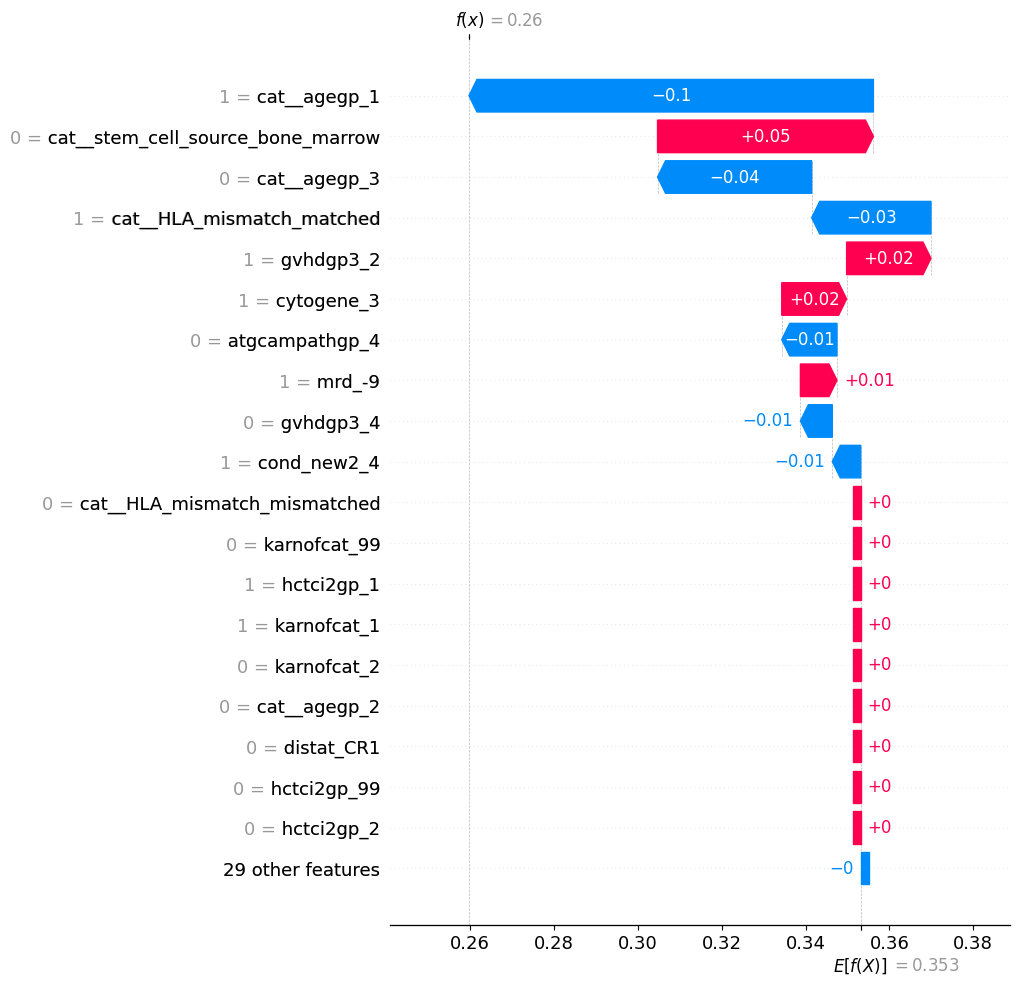

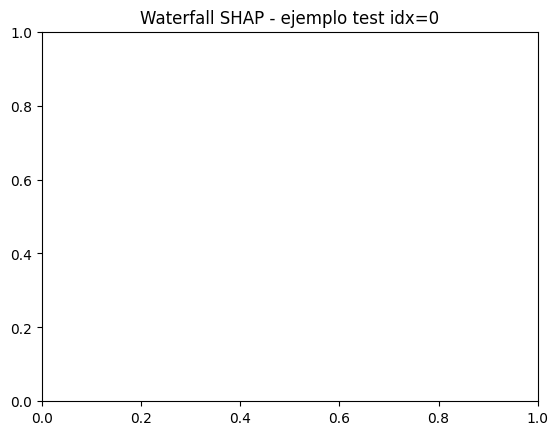

In [ ]:
import shap
import matplotlib.pyplot as plt

idx = 0
exp = shap.Explanation(
    values      = shap_values[idx],
    base_values = explainer.expected_value,
    data        = X_test_sample[idx],
    feature_names = feature_names,
)

shap.plots.waterfall(exp, max_display=20)
plt.title(f"Waterfall SHAP - ejemplo test idx={idx}")
plt.show()


#PDP/ALE

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasTwoInputWrapper(BaseEstimator, ClassifierMixin):

    def __init__(self, keras_model, n_exist, feature_names=None):
        self.model = keras_model
        self.n_exist = n_exist
        self.feature_names_in_ = np.array(feature_names) if feature_names is not None else None
        self.classes_ = np.array([0, 1])  # 0 = no GvHD, 1 = GvHD

    def fit(self, X, y=None):
        # Does not retrain: it only exists to comply with the sklearn interface
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X_e = X[:, :self.n_exist]
        X_n = X[:, self.n_exist:]
        proba_pos = self.model.predict([X_e, X_n], verbose=0).ravel()
        proba_neg = 1.0 - proba_pos
        return np.vstack([proba_neg, proba_pos]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

wrapper = KerasTwoInputWrapper(model, n_exist, feature_names)

# DataFrame with all features
X_train_df = pd.DataFrame(X_train_all, columns=feature_names)


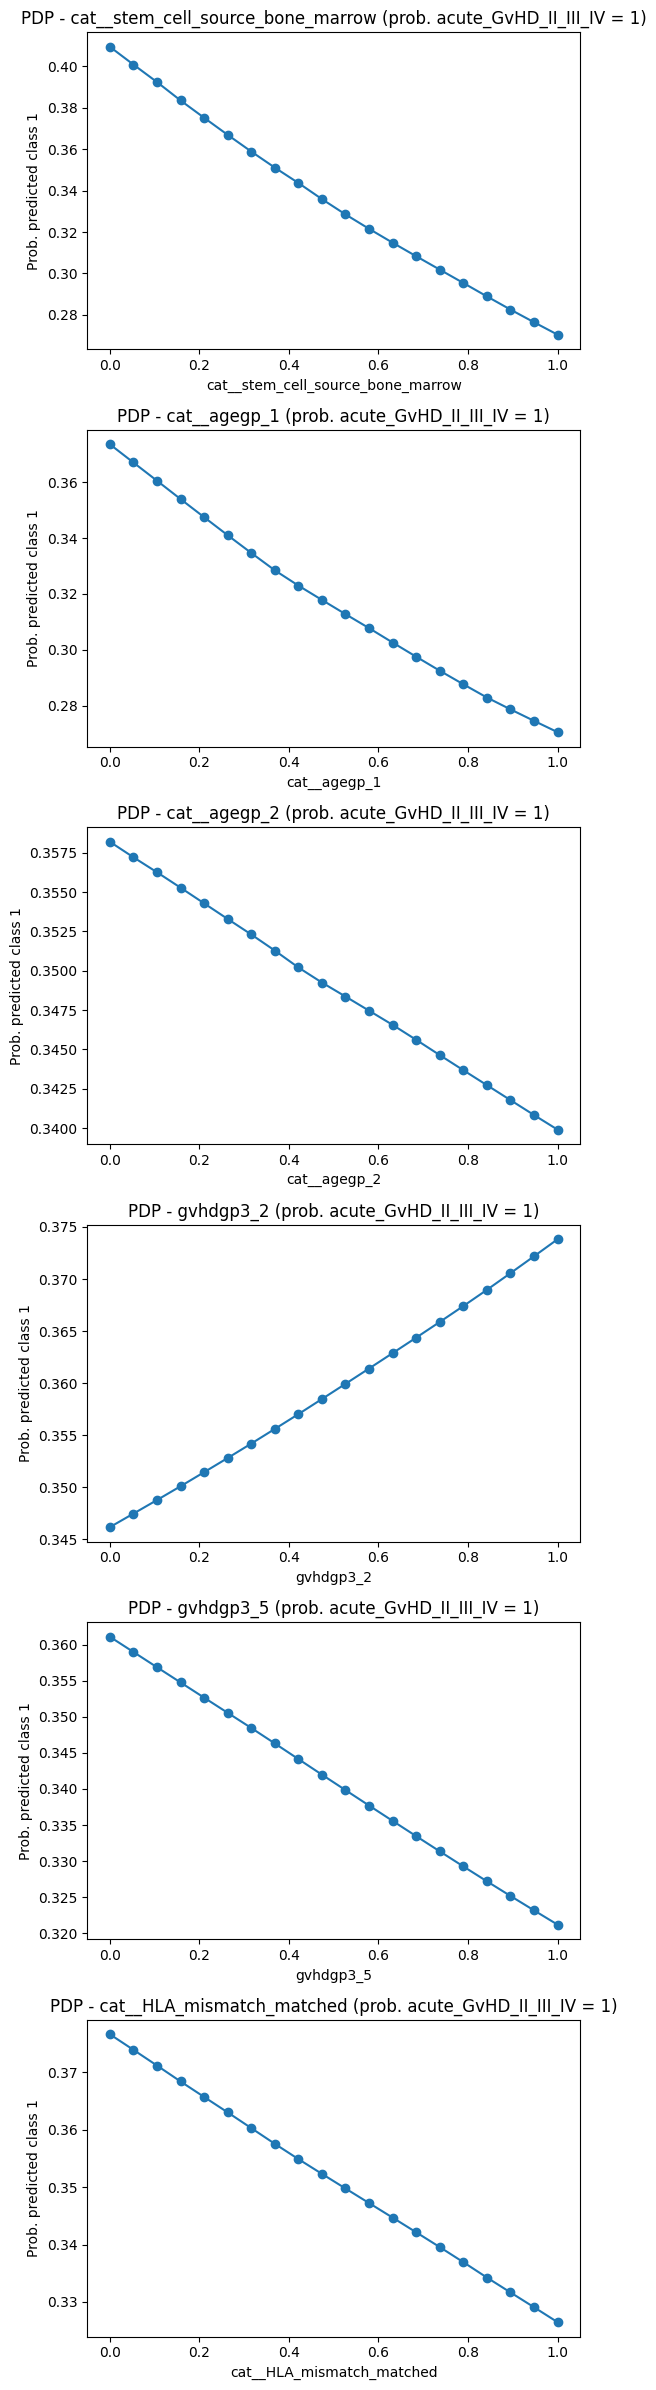

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_pdp_1d(model, X_df, feature, grid=None, grid_resolution=20, class_idx=1):

    x = X_df[feature].values

    # Si no damos grid, lo construimos:
    if grid is None:
        if np.issubdtype(x.dtype, np.number):
            # rango 5–95 percentil para evitar outliers extremos
            vmin, vmax = np.percentile(x, 5), np.percentile(x, 95)
            grid = np.linspace(vmin, vmax, grid_resolution)
        else:
            # categorical: we use the unique values
            grid = np.sort(pd.unique(x))

    pdp_vals = []
    X_tmp = X_df.copy()

    for val in grid:
        X_tmp[feature] = val
        proba = model.predict_proba(X_tmp.values)[:, class_idx]
        pdp_vals.append(proba.mean())

    return np.array(grid), np.array(pdp_vals)

# --------- features to analize ---------
features_pdp = [
    "cat__stem_cell_source_bone_marrow",

    "cat__agegp_1",
    "cat__agegp_2",
    "gvhdgp3_2",
    "gvhdgp3_5",
    "cat__HLA_mismatch_matched",
]

fig, axes = plt.subplots(len(features_pdp), 1, figsize=(6, 4 * len(features_pdp)))

if len(features_pdp) == 1:
    axes = [axes]

for ax, feat in zip(axes, features_pdp):
    grid, pdp_vals = compute_pdp_1d(wrapper, X_train_df, feat)
    ax.plot(grid, pdp_vals, marker="o")
    ax.set_title(f"PDP - {feat} (prob. acute_GvHD_II_III_IV = 1)")
    ax.set_ylabel("Prob. predicted class 1")
    ax.set_xlabel(feat)

plt.tight_layout()
plt.tight_layout()
# ✅ Save in high quality
out_pdf = "pdp_plots_highres.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")

plt.show()



INFO:PyALE._ALE_generic:Discrete feature detected.


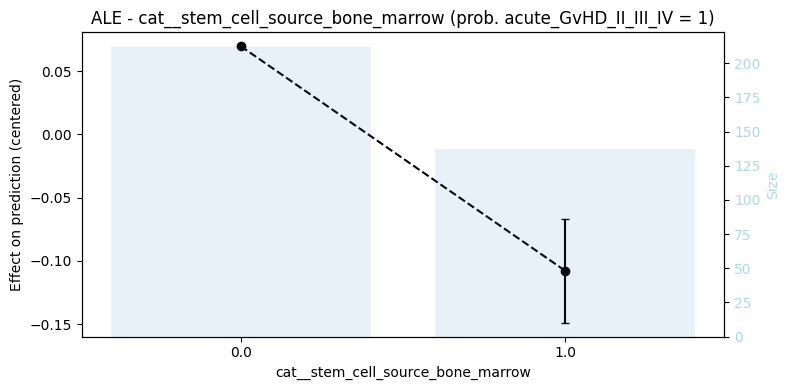

INFO:PyALE._ALE_generic:Discrete feature detected.


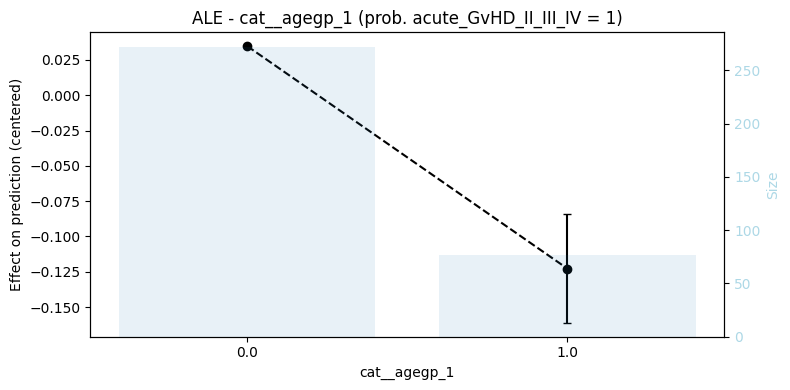

INFO:PyALE._ALE_generic:Discrete feature detected.


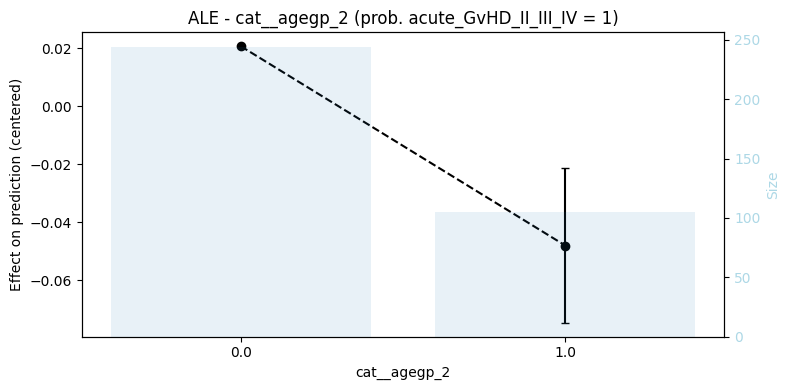

INFO:PyALE._ALE_generic:Discrete feature detected.


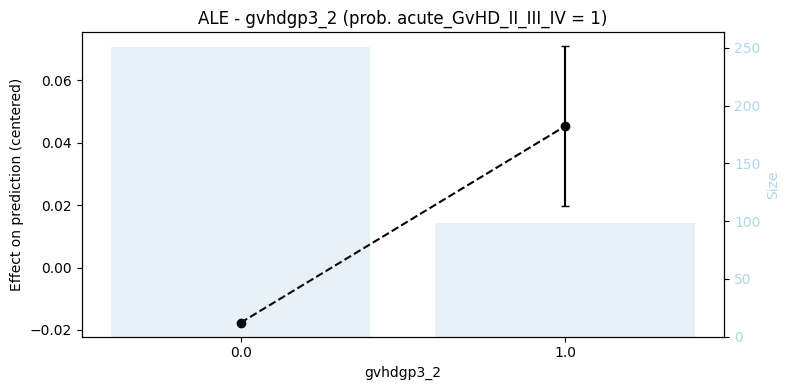

INFO:PyALE._ALE_generic:Discrete feature detected.


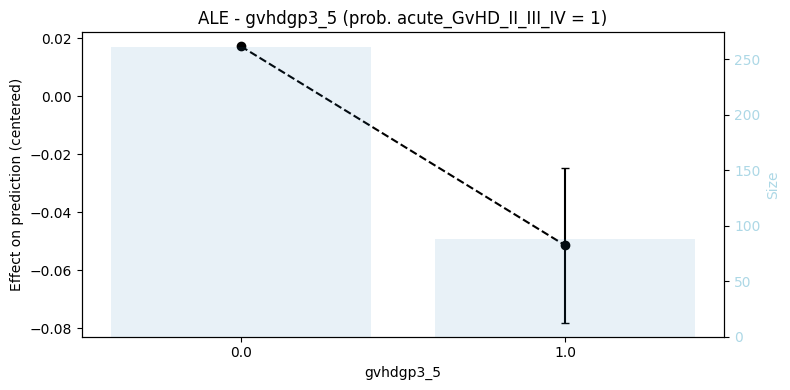

INFO:PyALE._ALE_generic:Discrete feature detected.


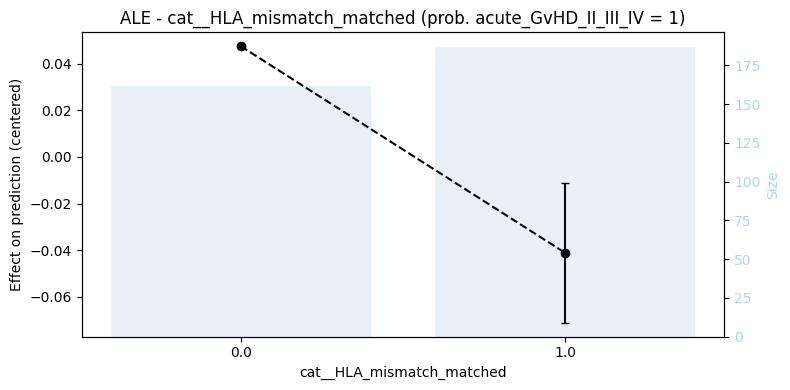

In [ ]:
!pip install PyALE

from PyALE import ale
import matplotlib.pyplot as plt

# ALE for recipient age
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__stem_cell_source_bone_marrow"],
    grid_size=20,
)
plt.title("ALE - cat__stem_cell_source_bone_marrow (prob. acute_GvHD_II_III_IV = 1)")
out_pdf1 = "ALE_cat__stem_cell_source_bone_marrow.pdf"
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")
plt.show()


# ALE for recipient age
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__agegp_1"],
    grid_size=20,
)
plt.title("ALE - cat__agegp_1 (prob. acute_GvHD_II_III_IV = 1)")
out_pdf2 = "ALE_cat__agegp_1.pdf"
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

# ALE for HLA_match
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__agegp_2"],
    grid_size=10,
)
plt.title("ALE - cat__agegp_2 (prob. acute_GvHD_II_III_IV = 1)")
out_pdf3 = "ALE_cat__agegp_2.pdf"
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

# ALE for donor_CMV_absent (binary 0/1)
ale(
    X=X_train_df,
    model=wrapper,
    feature=["gvhdgp3_2"],
    grid_size=2,
)
plt.title("ALE - gvhdgp3_2 (prob. acute_GvHD_II_III_IV = 1)")
out_pdf4 = "ALE_gvhdgp3_2.pdf"
plt.savefig(out_pdf4, format="pdf", bbox_inches="tight")
plt.show()

# ALE for donor_CMV_absent (binary 0/1)
ale(
    X=X_train_df,
    model=wrapper,
    feature=["gvhdgp3_5"],
    grid_size=2,
)
plt.title("ALE - gvhdgp3_5 (prob. acute_GvHD_II_III_IV = 1)")
out_pdf5 = "ALE_gvhdgp3_5.pdf"
plt.savefig(out_pdf5, format="pdf", bbox_inches="tight")
plt.show()

# ALE for donor_CMV_absent (binary 0/1)
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__HLA_mismatch_matched"],
    grid_size=2,
)
plt.title("ALE - cat__HLA_mismatch_matched (prob. acute_GvHD_II_III_IV = 1)")
out_pdf6 = "ALE_cat__HLA_mismatch_matched.pdf"
plt.savefig(out_pdf6, format="pdf", bbox_inches="tight")
plt.show()


#Dalex

In [ ]:
class KerasTwoInputWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, keras_model, n_exist, feature_names=None):
        self.model = keras_model
        self.n_exist = n_exist
        self.feature_names_in_ = np.array(feature_names) if feature_names is not None else None
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X_e = X[:, :self.n_exist]
        X_n = X[:, self.n_exist:]
        proba_pos = self.model.predict([X_e, X_n], verbose=0).ravel()
        proba_neg = 1.0 - proba_pos
        return np.vstack([proba_neg, proba_pos]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

wrapper = KerasTwoInputWrapper(model, n_exist, feature_names)


In [ ]:
X_train_df = pd.DataFrame(X_train_all, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_all,  columns=feature_names)


In [ ]:
!pip install dalex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 62.2 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import dalex as dx
import numpy as np
# Make sure y_train is a 1D vector of 0/1
y_train_1d = np.array(y_train).ravel()



def predict_proba_pos(model, data):
    """
    DALEX la va a llamar como predict_proba_pos(model, data)

    - model: nuestro wrapper (KerasTwoInputWrapper)
    - data: DataFrame o array con las features
    """
    proba = model.predict_proba(data)
    return proba[:, 1]




exp_dalex = dx.Explainer(
    model=wrapper,
    data=X_train_df,
    y=y_train_1d,
    predict_function=predict_proba_pos,
    label="Dalex Global Feature Importance on UCHW dataset - model BMTCH-UCHW",
)


Preparation of a new explainer is initiated

  -> data              : 349 rows 48 cols
  -> target variable   : 349 values
  -> model_class       : __main__.KerasTwoInputWrapper (default)
  -> label             : Dalex Global Feature Importance on UCHW dataset - model BMTCH-UCHW
  -> predict function  : <function predict_proba_pos at 0x79b2c390c4a0> will be used
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.121, mean = 0.353, max = 0.64
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.637, mean = 0.00781, max = 0.87
  -> model_info        : package __main__

A new explainer has been created!


In [ ]:
vi = exp_dalex.model_parts(type="variable_importance")
vi.result.head()
fig = vi.plot(max_vars=20,show=False)
pio.write_image(
    fig,
    "dalex_variable_importance.pdf",
    format="pdf",
    width=1400,   # controls size/layout
    height=900
)
vi.plot(max_vars=20)

/tmp/ipykernel_1401/2998916168.py:4: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  pio.write_image(


In [ ]:
pdp_graft = exp_dalex.model_profile(
    variables=["Graft_manipulation_CD-34+-selection"],
    type="partial"
)

pdp_graft.plot()